# Supplementary Figure 3: robustness supporting Figure 3


In [1]:
######## manual snakemake preamble (standalone execution, bypasses Snakemake DAG) ########
library(methods)
Snakemake <- setClass(
    "Snakemake",
    slots = c(
        input = "list", output = "list", params = "list", wildcards = "list",
        threads = "numeric", log = "list", resources = "list", config = "list",
        rule = "character", bench_iteration = "numeric", scriptdir = "character",
        source = "function"
    )
)
snakemake <- Snakemake(
    input = list(
        "ari_data" = '/home/msubirana/Documents/pivlab/clamp-analyses-gtex-timing/output/03_model_biology/01_gtex/00_kmeans_clustering/ari_data.csv',
        "ari_comparisons" = '/home/msubirana/Documents/pivlab/clamp-analyses-gtex-timing/output/03_model_biology/01_gtex/00_kmeans_clustering/ari_comparisons.csv',
        "gene_fraction_ari_data" = '/home/msubirana/Documents/pivlab/clamp-analyses-gtex-timing/output/03_model_biology/01_gtex/00_kmeans_clustering/gene_fraction_ari_data.csv',
        "gene_fraction_ari_comparisons" = '/home/msubirana/Documents/pivlab/clamp-analyses-gtex-timing/output/03_model_biology/01_gtex/00_kmeans_clustering/gene_fraction_ari_comparisons.csv',
        "tissue_subtissue_heatmap" = '/home/msubirana/Documents/pivlab/clamp-analyses-gtex-timing/output/03_model_biology/01_gtex/02_LV_importance_rf_true_labels_biology/tissue_subtissue_heatmap.csv',
        "z_matrix_subtissue" = '/home/msubirana/Documents/pivlab/clamp-analyses-gtex-timing/output/03_model_biology/01_gtex/07_global_alignment_rf_true_labels/cumulative20/gtex_global_alignment_summary.csv',
        "runtime_gtex_per_fit" = '/home/msubirana/Documents/pivlab/clamp-analyses-gtex-timing/output/02_model_performance/01_gtex/00_computational_timing/runtime_per_fit.csv'
    ),
    output = list(
        "png" = '/home/msubirana/Documents/pivlab/clamp-analyses-gtex-timing/output/99_panels/supp3/supp3.png',
        "pdf" = '/home/msubirana/Documents/pivlab/clamp-analyses-gtex-timing/output/99_panels/supp3/supp3.pdf',
        "svg" = '/home/msubirana/Documents/pivlab/clamp-analyses-gtex-timing/output/99_panels/supp3/supp3.svg',
        "complete" = '/home/msubirana/Documents/pivlab/clamp-analyses-gtex-timing/output/99_panels/supp3/notebook.complete'
    ),
    params = list(), wildcards = list(), threads = 1,
    log = list("notebook" = '/home/msubirana/Documents/pivlab/clamp-analyses-gtex-timing/nbs/99_panels/supp3.executed.ipynb'),
    resources = list("tmpdir" = '/tmp'), config = list(),
    rule = 'supp3_panel', bench_iteration = as.numeric(NA),
    scriptdir = '/home/msubirana/Documents/pivlab/clamp-analyses-gtex-timing/nbs/99_panels',
    source = function(...){
        wd <- getwd(); setwd(snakemake@scriptdir); source(...); setwd(wd)
    }
)
setwd('/home/msubirana/Documents/pivlab/clamp-analyses-gtex-timing');
######## manual preamble end #########

supp3: 183 x 255 mm


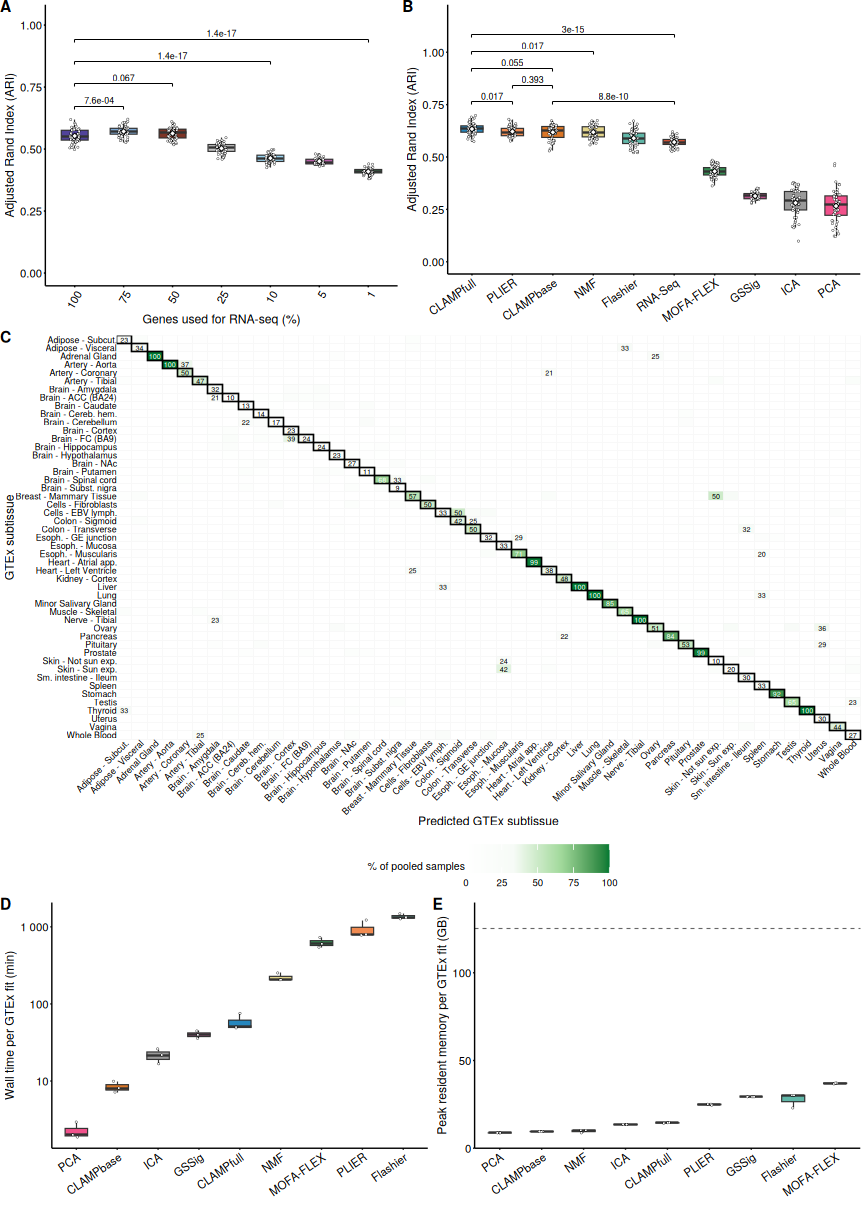

In [2]:
suppressPackageStartupMessages({
  library(data.table)
  library(ggplot2)
  library(patchwork)
  library(cowplot)
  library(scales)
  library(yaml)
  library(here)
  library(grid)
  library(svglite)
  library(ragg)
})

dir.create(dirname(snakemake@output[["pdf"]]), recursive = TRUE, showWarnings = FALSE)

FIG_W <- 183
FIG_H <- 255
FONT_FAMILY <- "Helvetica"
FS_TAG <- 9
FS_AXIS_TITLE <- 7
FS_AXIS_TEXT <- 6.5
FS_LEGEND <- 5.5
FS_LEGEND_TITLE <- 6
FS_DENSE_VALUE <- 4
FS_HEAT_LABEL_H <- 5
LINE_W <- 0.3

cfg <- yaml::read_yaml(here("config.yaml"))
MODEL_COLORS_RAW <- unlist(cfg$MODEL_COLORS)
names(MODEL_COLORS_RAW)[names(MODEL_COLORS_RAW) == "GenomicSuperSignature"] <- "GSSig"
GREEN_SCALE <- unlist(cfg$GREEN_SCALE)
TILE_TEXT <- c("TRUE" = "white", "FALSE" = "black")

pt_mm <- function(pt) pt / .pt

theme_nm <- function(base_size = FS_AXIS_TEXT) {
  theme_classic(base_size = base_size, base_family = FONT_FAMILY) %+replace%
    theme(
      axis.line = element_line(linewidth = LINE_W, colour = "black"),
      axis.ticks = element_line(linewidth = LINE_W, colour = "black"),
      axis.ticks.length = unit(0.9, "pt"),
      axis.text = element_text(size = base_size, colour = "black"),
      axis.title = element_text(size = FS_AXIS_TITLE, colour = "black"),
      legend.text = element_text(size = FS_LEGEND),
      legend.title = element_text(size = FS_LEGEND_TITLE),
      legend.key = element_blank(), legend.background = element_blank(),
      panel.grid = element_blank(), plot.background = element_blank(),
      plot.margin = margin(1, 1, 1, 1, "mm")
    )
}

theme_heatmap <- function() {
  theme_nm() %+replace%
    theme(axis.line = element_blank(), axis.ticks = element_blank(),
          axis.text.x = element_text(size = FS_HEAT_LABEL_H, angle = 45,
                                     hjust = 1, vjust = 1, lineheight = 0.9),
          axis.text.y = element_text(size = FS_HEAT_LABEL_H, hjust = 1,
                                     lineheight = 0.9),
          plot.margin = margin(1, 1, 1, 1, "mm"))
}

add_tag <- function(p, label) {
  ggdraw() + draw_plot(p) +
    draw_label(label, x = 0, y = 1, hjust = 0, vjust = 1,
               size = FS_TAG, fontface = "bold", fontfamily = FONT_FAMILY)
}

assign_bracket_tiers <- function(comp_df, xpos) {
  d <- copy(as.data.table(comp_df))
  d[, left := pmin(xpos[a], xpos[b])]
  d[, right := pmax(xpos[a], xpos[b])]
  d[, span := right - left]
  setorder(d, span, left)
  tiers <- list()
  d[, tier := 0L]
  for (i in seq_len(nrow(d))) {
    t <- 1L
    while (length(tiers) >= t && any(d$left[i] <= tiers[[t]]$right &
                                      d$right[i] >= tiers[[t]]$left)) t <- t + 1L
    d$tier[i] <- t
    if (length(tiers) < t) tiers[[t]] <- d[i, .(left, right)]
    else tiers[[t]] <- rbind(tiers[[t]], d[i, .(left, right)])
  }
  d[, span := NULL]
  d
}

fmt_q <- function(q) {
  if (is.na(q)) return("n.a.")
  if (q >= 0.001) return(sprintf("%.3f", q))
  format(q, scientific = TRUE, digits = 2)
}

add_brackets <- function(p, d, y_base, y_step, h, size) {
  for (i in seq_len(nrow(d))) {
    y <- y_base + (d$tier[i] - 1) * y_step
    p <- p +
      annotate("segment", x = d$left[i], xend = d$left[i], y = y, yend = y + h,
               linewidth = 0.22) +
      annotate("segment", x = d$left[i], xend = d$right[i], y = y + h, yend = y + h,
               linewidth = 0.22) +
      annotate("segment", x = d$right[i], xend = d$right[i], y = y, yend = y + h,
               linewidth = 0.22) +
      annotate("text", x = (d$left[i] + d$right[i]) / 2, y = y + h + 0.01,
               label = fmt_q(d$q[i]), size = size, vjust = 0,
               family = FONT_FAMILY)
  }
  p
}

shorten_gtex <- function(x) {
  x <- gsub("Adipose - Subcutaneous", "Adipose - Subcut.", x)
  x <- gsub("Adipose - Visceral \\(Omentum\\)", "Adipose - Visceral", x)
  x <- gsub("Brain - Anterior cingulate cortex \\(BA24\\)", "Brain - ACC (BA24)", x)
  x <- gsub("Brain - Caudate \\(basal ganglia\\)", "Brain - Caudate", x)
  x <- gsub("Brain - Cerebellar Hemisphere", "Brain - Cereb. hem.", x)
  x <- gsub("Brain - Frontal Cortex \\(BA9\\)", "Brain - FC (BA9)", x)
  x <- gsub("Brain - Nucleus accumbens \\(basal ganglia\\)", "Brain - NAc", x)
  x <- gsub("Brain - Putamen \\(basal ganglia\\)", "Brain - Putamen", x)
  x <- gsub("Brain - Spinal cord \\(cervical c-1\\)", "Brain - Spinal cord", x)
  x <- gsub("Brain - Substantia nigra", "Brain - Subst. nigra", x)
  x <- gsub("Cells - Cultured fibroblasts", "Cells - Fibroblasts", x)
  x <- gsub("Cells - EBV-transformed lymphocytes", "Cells - EBV lymph.", x)
  x <- gsub("Esophagus - Gastroesophageal Junction", "Esoph. - GE junction", x)
  x <- gsub("Esophagus - Mucosa", "Esoph. - Mucosa", x)
  x <- gsub("Esophagus - Muscularis", "Esoph. - Muscularis", x)
  x <- gsub("Heart - Atrial Appendage", "Heart - Atrial app.", x)
  x <- gsub("Skin - Not Sun Exposed \\(Suprapubic\\)", "Skin - Not sun exp.", x)
  x <- gsub("Skin - Sun Exposed \\(Lower leg\\)", "Skin - Sun exp.", x)
  x <- gsub("Small Intestine - Terminal Ileum", "Sm. intestine - Ileum", x)
  trimws(x)
}

# A: RNA-seq gene-subsampling robustness.
gene_frac <- fread(snakemake@input[["gene_fraction_ari_data"]])
gene_comp <- fread(snakemake@input[["gene_fraction_ari_comparisons"]])
fraction_levels <- c("100%", "75%", "50%", "25%", "10%", "5%", "1%")
gene_frac[, fraction := factor(fraction, levels = fraction_levels)]
fraction_colours <- unlist(cfg$RNASEQ_FRACTION_COLORS)[fraction_levels]
mean_gene <- gene_frac[, .(mean_ari = mean(ari), max_ari = max(ari)), by = fraction]
gene_comp <- gene_comp[a == "100%" & b %in% c("75%", "50%", "10%", "1%")]
gene_comp <- assign_bracket_tiers(gene_comp,
                                  setNames(seq_along(fraction_levels), fraction_levels))
y0 <- max(mean_gene$max_ari) + 0.04
ystep <- 0.09
ymax <- y0 + (max(gene_comp$tier) - 1) * ystep + 0.10
panel_A <- ggplot(gene_frac, aes(fraction, ari, fill = fraction)) +
  geom_boxplot(width = 0.55, outlier.shape = NA, linewidth = 0.25, alpha = 0.85) +
  geom_jitter(width = 0.10, size = 0.3, shape = 21, fill = "white", stroke = 0.12) +
  geom_point(data = mean_gene, aes(x = fraction, y = mean_ari), shape = 23, size = 1.1,
             fill = "white", inherit.aes = FALSE) +
  scale_fill_manual(values = fraction_colours) +
  scale_x_discrete(labels = sub("%$", "", fraction_levels)) +
  scale_y_continuous(breaks = seq(0, 1, 0.25)) +
  coord_cartesian(ylim = c(0, ymax), clip = "on") +
  labs(x = "Genes used for RNA-seq (%)", y = "Adjusted Rand Index (ARI)") +
  theme_nm() +
  theme(legend.position = "none", axis.text.x = element_text(angle = 60, hjust = 1))
panel_A <- add_brackets(panel_A, gene_comp, y0, ystep, 0.012, pt_mm(5))

# B: method-level GTEx clustering benchmark.
ari <- fread(snakemake@input[["ari_data"]])
ari_comp <- fread(snakemake@input[["ari_comparisons"]])
ari[, method := fifelse(method == "GenomicSuperSignature", "GSSig", method)]
ari_comp[, a := fifelse(a == "GenomicSuperSignature", "GSSig", a)]
ari_comp[, b := fifelse(b == "GenomicSuperSignature", "GSSig", b)]
method_means <- ari[, .(m = mean(ari)), by = method]
pinned <- c("CLAMPfull", "PLIER", "CLAMPbase", "NMF")
pinned <- pinned[pinned %in% method_means$method]
method_levels <- c(pinned, method_means[!method %in% pinned][order(-m), method])
ari[, method := factor(method, levels = method_levels)]
mean_ari <- ari[, .(mean_ari = mean(ari), max_ari = max(ari)), by = method]
mean_ari[, method := factor(method, levels = method_levels)]
ari_comp <- assign_bracket_tiers(ari_comp,
                                 setNames(seq_along(method_levels), method_levels))
y0b <- max(mean_ari$max_ari) + 0.05
ystepb <- 0.08
ymaxb <- y0b + (max(ari_comp$tier) - 1) * ystepb + 0.10
method_colours <- MODEL_COLORS_RAW[method_levels]
method_colours[is.na(method_colours)] <- "grey70"
panel_B <- ggplot(ari, aes(method, ari, fill = method)) +
  geom_boxplot(width = 0.55, outlier.shape = NA, linewidth = 0.25, alpha = 0.85) +
  geom_jitter(width = 0.10, size = 0.3, shape = 21, fill = "white", stroke = 0.12) +
  geom_point(data = mean_ari, aes(x = method, y = mean_ari), shape = 23, size = 1.1,
             fill = "white", inherit.aes = FALSE) +
  scale_fill_manual(values = method_colours) +
  scale_y_continuous(breaks = seq(0, 1, 0.25)) +
  coord_cartesian(ylim = c(0, ymaxb), clip = "on") +
  labs(x = NULL, y = "Adjusted Rand Index (ARI)") +
  theme_nm() +
  theme(legend.position = "none", axis.text.x = element_text(angle = 35, hjust = 1))
panel_B <- add_brackets(panel_B, ari_comp, y0b, ystepb, 0.015, pt_mm(5))

# C: subtissue B-matrix concordance with Z-matrix confirmation.
hm <- fread(snakemake@input[["tissue_subtissue_heatmap"]])
z <- fread(snakemake@input[["z_matrix_subtissue"]])
hm_order <- sort(unique(hm$Tissue))
hm_short <- shorten_gtex(hm_order)
hm[, row_lab := factor(shorten_gtex(Tissue), levels = rev(hm_short))]
hm[, col_lab := factor(shorten_gtex(Predicted_Tissue), levels = hm_short)]
hm[, is_diagonal := Tissue == Predicted_Tissue]
hm[, offdiag_rank := frank(fifelse(is_diagonal, Inf, -Pct), ties.method = "first"),
   by = Tissue]
hm[, show_label := is_diagonal | (!is_diagonal & Pct >= 20 & offdiag_rank == 1)]
diag_cells <- merge(hm[Tissue == Predicted_Tissue], z[, .(Tissue, tissue_correct)],
                    by.x = "Predicted_Tissue", by.y = "Tissue", all.x = TRUE)
panel_C <- ggplot(hm, aes(col_lab, row_lab, fill = Pct)) +
  geom_tile(colour = "#f0f0f0", linewidth = 0.1) +
  geom_tile(data = diag_cells[tissue_correct == TRUE], fill = NA, colour = "black",
            linewidth = 0.35) +
  geom_tile(data = diag_cells[tissue_correct == FALSE], fill = NA, colour = "red",
            linetype = "22", linewidth = 0.35) +
  geom_text(data = hm[show_label == TRUE],
            aes(label = sprintf("%.0f", Pct), colour = Pct >= 65),
            size = pt_mm(FS_DENSE_VALUE), check_overlap = TRUE, show.legend = FALSE) +
  scale_fill_gradientn(colours = GREEN_SCALE, limits = c(0, 100),
                       name = "% of pooled samples") +
  scale_colour_manual(values = TILE_TEXT, guide = "none") +
  scale_x_discrete(expand = c(0, 0)) + scale_y_discrete(expand = c(0, 0)) +
  labs(x = "Predicted GTEx subtissue", y = "GTEx subtissue") +
  theme_heatmap() +
  theme(legend.position = "bottom", legend.direction = "horizontal")

# D-E: GTEx computational-timing benchmark (wall time, peak memory).
runtime_gtex <- fread(snakemake@input[["runtime_gtex_per_fit"]])
stopifnot(all(c("method", "seed", "elapsed_minutes", "peak_rss_gb") %in% names(runtime_gtex)),
          nrow(runtime_gtex) == 27L,
          all(is.finite(runtime_gtex$elapsed_minutes)),
          all(runtime_gtex$elapsed_minutes > 0))

timing_method_order <- runtime_gtex[, .(median_minutes = median(elapsed_minutes)),
                                    by = method][order(median_minutes), method]
runtime_gtex_time <- copy(runtime_gtex)
runtime_gtex_time[, method := factor(method, levels = timing_method_order)]
timing_colours <- MODEL_COLORS_RAW[as.character(timing_method_order)]
timing_colours[is.na(timing_colours)] <- "grey70"
panel_D <- ggplot(runtime_gtex_time, aes(method, elapsed_minutes, fill = method)) +
  geom_boxplot(width = 0.55, outlier.shape = NA, linewidth = 0.25, alpha = 0.85) +
  geom_jitter(width = 0.10, size = 0.3, shape = 21, fill = "white", stroke = 0.12) +
  scale_fill_manual(values = timing_colours, guide = "none") +
  scale_y_log10(breaks = scales::log_breaks(n = 5), labels = scales::label_number()) +
  labs(x = NULL, y = "Wall time per GTEx fit (min)") +
  theme_nm() +
  theme(axis.text.x = element_text(angle = 35, hjust = 1))

memory_method_order <- runtime_gtex[, .(median_peak_rss_gb = median(peak_rss_gb)),
                                    by = method][order(median_peak_rss_gb), method]
runtime_gtex_mem <- copy(runtime_gtex)
runtime_gtex_mem[, method := factor(method, levels = memory_method_order)]
memory_colours <- MODEL_COLORS_RAW[as.character(memory_method_order)]
memory_colours[is.na(memory_colours)] <- "grey70"
panel_E <- ggplot(runtime_gtex_mem, aes(method, peak_rss_gb, fill = method)) +
  geom_boxplot(width = 0.55, outlier.shape = NA, linewidth = 0.25, alpha = 0.85) +
  geom_jitter(width = 0.10, size = 0.3, shape = 21, fill = "white", stroke = 0.12) +
  geom_hline(yintercept = 125, linetype = "dashed", colour = "grey40", linewidth = 0.25) +
  scale_fill_manual(values = memory_colours, guide = "none") +
  scale_y_continuous(limits = c(0, NA), expand = expansion(mult = c(0, 0.12))) +
  labs(x = NULL, y = "Peak resident memory per GTEx fit (GB)") +
  theme_nm() +
  theme(axis.text.x = element_text(angle = 35, hjust = 1))

top <- plot_grid(add_tag(panel_A, "A"), add_tag(panel_B, "B"), nrow = 1,
                 rel_widths = c(1, 1.15))
bottom <- plot_grid(add_tag(panel_D, "D"), add_tag(panel_E, "E"), nrow = 1)
supp3 <- plot_grid(top, add_tag(panel_C, "C"), bottom, ncol = 1,
                   rel_heights = c(70, 120, 65))

raw_pdf <- tempfile(fileext = ".pdf")
exact_pdf <- tempfile(fileext = ".pdf")
ggsave(raw_pdf, supp3, width = FIG_W, height = FIG_H, units = "mm",
       device = cairo_pdf, bg = "white", limitsize = FALSE)
pdf_w_pt <- FIG_W / 25.4 * 72
pdf_h_pt <- FIG_H / 25.4 * 72
gs_status <- system2("gs", c("-q", "-dNOPAUSE", "-dBATCH", "-sDEVICE=pdfwrite",
  sprintf("-dDEVICEWIDTHPOINTS=%.6f", pdf_w_pt),
  sprintf("-dDEVICEHEIGHTPOINTS=%.6f", pdf_h_pt), "-dFIXEDMEDIA", "-dPDFFitPage",
  paste0("-sOutputFile=", exact_pdf), raw_pdf))
stopifnot(gs_status == 0L,
          file.copy(exact_pdf, snakemake@output[["pdf"]], overwrite = TRUE))
unlink(c(raw_pdf, exact_pdf))
ggsave(snakemake@output[["svg"]], supp3, width = FIG_W, height = FIG_H,
       units = "mm", device = svglite::svglite, bg = "white", limitsize = FALSE)
ggsave(snakemake@output[["png"]], supp3, width = FIG_W, height = FIG_H,
       units = "mm", dpi = 600, device = ragg::agg_png, bg = "white",
       limitsize = FALSE)
cat(sprintf("supp3: %.0f x %.0f mm\n", FIG_W, FIG_H))
options(repr.plot.width = FIG_W / 25.4, repr.plot.height = FIG_H / 25.4)
supp3
